<a href="https://colab.research.google.com/github/rutkowskaa/lecture1/blob/main/PUM10_systemy_rekomendacyjne_cz2_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dane https://grouplens.org/datasets/movielens/32m/


In [2]:
ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())
movies = pd.read_csv('/content/movies.csv')


   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858


Wczytanie plikow z selekcja uzytkownikow - tylko dla cwiczenia cz2. w celu redukcji danych

In [3]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())

movies = pd.read_csv('/content/movies.csv')

# policz liczbę ocen na użytkownika
user_activity = ratings['userId'].value_counts()

# wybierz 100 najbardziej aktywnych użytkowników
top_users = user_activity.head(100).index

# przefiltruj dane
ratings = ratings[ratings['userId'].isin(top_users)]

# opcjonalnie sprawdź wynik
print("Liczba rekordów po filtracji:", len(ratings))
print("Liczba użytkowników:", ratings['userId'].nunique())


   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858
Liczba rekordów po filtracji: 522105
Liczba użytkowników: 100


Poznaj dane:


1.   Ile jest ocen filmów?
2.   Ile filmów w bazie?
3.   Ile użytkowników?
4.   Jaka jest średnia liczba ocen na użytkownika i na film?



In [4]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
#n_movies = movies['movieId'].nunique()
n_users = len(ratings['userId'].unique())

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 522105
Number of unique movieId's: 58855
Number of unique users: 100
Average number of ratings per user: 5221.05
Average number of ratings per movie: 8.87


Jak wygląda rozkład ocen filmów?




/tmp/ipykernel_17434/2038653828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=ratings, palette="viridis")


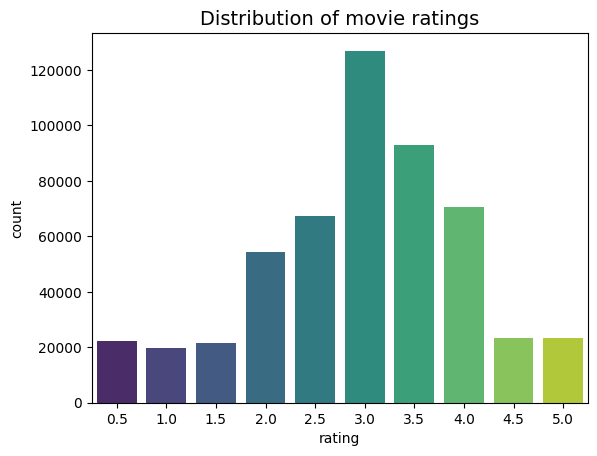

In [5]:
sns.countplot(x="rating", data=ratings, palette="viridis")
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

In [6]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings['title'].value_counts()[0:10]

,count
title,
War of the Worlds (2005),102
Alien (1979),100
Star Wars: Episode IV - A New Hope (1977),100
Confessions of a Dangerous Mind (2002),99
Star Wars: Episode V - The Empire Strikes Back (1980),99
"Shining, The (1980)",99
"Silence of the Lambs, The (1991)",99
Iron Man (2008),99
Pulp Fiction (1994),99


In [7]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean global rating: 2.97.
Mean rating per user: 2.98.


In [8]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
print(movies[movies['movieId']==lowest_rated])
highest_rated = mean_ratings['rating'].idxmax()
print(movies[movies['movieId'] == highest_rated])

     movieId                  title  genres
640      651  Superweib, Das (1996)  Comedy
      movieId          title                genres
5513     5622  Charly (2002)  Comedy|Drama|Romance


In [9]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
5513,5622,Charly (2002),Comedy|Drama|Romance


In [10]:
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()

In [11]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return bayesian_avg

bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']

movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')
movie_stats.describe()

,movieId,count,mean,bayesian_avg
count,58855.000000,58855.000000,58855.000000,58855.000000
mean,133239.751780,8.871039,2.828458,2.846105
std,77182.127914,15.813684,0.814211,0.216012
min,1.000000,1.000000,0.500000,1.493453
25%,79544.000000,1.000000,2.500000,2.744530
50%,142628.000000,2.000000,3.000000,2.845836
75%,189092.000000,8.000000,3.333333,2.952005
max,292541.000000,100.000000,5.000000,4.246529


In [12]:
movie_ratings['movieId'].nunique()
M = movie_ratings['userId'].nunique()
user_mapper = dict(zip(np.unique(movie_ratings["userId"]), list(range(M))))

In [13]:
from scipy.sparse import csr_matrix

def create_sparse(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index, item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_sparse(ratings)

In [14]:
sparsity = X.count_nonzero()/(X.shape[0]*X.shape[1])

print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 8.87%


Wykorzystaj algorytm najblizszych sąsiadów, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

In [15]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, k, metric='cosine', show_distance=False):
    """
    Finds k-nearest neighbours for a given movie id.

    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations

    Returns:
        list of k similar movie ID's
    """
    neighbour_ids = []

    # Transpose the user-item matrix X to an item-user matrix X_movies
    # Now, each row in X_movies corresponds to a movie, and columns to users
    X_movies = X.T

    # Get the internal index for the movie_id from movie_mapper
    # This index is a row index in X_movies
    target_movie_idx = movie_mapper[movie_id]

    # Extract the vector for the target movie from X_movies
    target_movie_vec = X_movies[target_movie_idx]

    # Initialize kNN model. k+1 because the movie itself will be the closest neighbor
    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X_movies) # Fit the model on the movie-user matrix

    # Reshape movie_vec if it's a 1D array to a 2D array for kneighbors
    if isinstance(target_movie_vec, (np.ndarray)):
        target_movie_vec = target_movie_vec.reshape(1,-1)

    # Find k+1 nearest neighbors (distances and indices)
    if show_distance:
        distances, indices = kNN.kneighbors(target_movie_vec, return_distance=True)
    else:
        indices = kNN.kneighbors(target_movie_vec, return_distance=False)

    # Iterate through the neighbors, skipping the first one (the movie itself)
    for i in range(1, len(indices[0])):
        # 'idx' is the internal index of the similar movie in the sparse matrix
        idx = indices[0][i]
        # Map this internal index back to the original movieId using movie_inv_mapper
        neighbour_ids.append(movie_inv_mapper[idx])

    return neighbour_ids

In [16]:
movie_titles = dict(zip(movies['movieId'], movies['title']))
movie_id = 1

similar_ids = find_similar_movies(movie_id, X, k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}")
for i in similar_ids:
    print(movie_titles[i])

Because you watched Toy Story (1995)
Toy Story 2 (1999)
Finding Nemo (2003)
Minority Report (2002)
Star Wars: Episode V - The Empire Strikes Back (1980)
Incredibles, The (2004)
Monsters, Inc. (2001)
Memento (2000)
Up (2009)
Seven (a.k.a. Se7en) (1995)
Shrek (2001)


Wykorzystaj algorytm SVD, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

cz1: klasyczne SVD (biblioteka **NumPy**)

In [17]:
import numpy as np

def svd_reconstruct(R, k=2):
    """
    Aproksymacja macierzy przez klasyczne SVD
    """

    return R_approx

cz2: TruncatedSVD (scikit-learn)


In [18]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

def truncated_svd_reconstruct(R, k=2):
    """
    Aproksymacja macierzy przez TruncatedSVD (sklearn)
    """


    return R_approx

wywołaj obie funkcje i stworz rekomentacje dla uzytkownika nr 10

In [34]:
user_id = list(user_mapper.keys())[0]
user_idx = user_mapper[user_id]


R_svd = svd_reconstruct(X.toarray(), k=20)   # UWAGA: musi być gęsta macierz

R_trunc = truncated_svd_reconstruct(X, k=2)

def get_recommendations(R_original, R_pred, user_idx):


    return sorted(recs, key=lambda x: x[1], reverse=True)

recs_svd =
recs =

print("Top 10  svd:")


print("-------------------------------")

print("Top 10 trunceted svd:")


Top 10  svd:
Inside Out (2015) 4.058756586929794
Blade Runner 2049 (2017) 3.70641534541611
The Jungle Book (2016) 3.4517159523078047
The Martian (2015) 3.4404685136377444
Finding Dory (2016) 3.4271147474064545
Solo: A Star Wars Story (2018) 3.384085420742511
Shawshank Redemption, The (1994) 3.3104636938809247
Her (2013) 3.236918842967211
Princess Bride, The (1987) 3.231086002789127
I, Tonya (2017) 3.179522118903943
-------------------------------
Top 10 trunceted svd:
Shawshank Redemption, The (1994) 3.7463809691649073
American Beauty (1999) 3.462486664603606
Braveheart (1995) 3.4306773586687513
Schindler's List (1993) 3.4205005694574515
Godfather, The (1972) 3.374057558642421
Stand by Me (1986) 3.2385164081966376
Big (1988) 3.2215717645829516
L.A. Confidential (1997) 3.17130214003655
The Martian (2015) 3.1701116539135863
Heat (1995) 3.0711724841923878


KLUCZOWA różnica (najważniejsze)
SVD:

* działa na pełnej macierzy
* traktuje brak ocen jako 0 → to jest BŁĄD modelowy

TruncatedSVD:

* działa na macierzy sparse
* ale nadal NIE rozróżnia: brak oceny vs słaba ocena



Ocena modeli - policz RSME na macierzach tylko na niezerowych elementach